<a href="https://colab.research.google.com/github/dmandache/IMPERANDI/blob/main/examples/demos/demo_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPERANDI × TCGA-LIHC — Full demo

A public end-to-end walkthrough using the same three TCGA-LIHC patients as the light demo. This notebook demonstrates **ingest → phase curation → convert → segmentation → radiomic feature extraction → interactive viewer → TorchIO preprocessing → PyTorch batch**.


## 1. Install dependencies


In [1]:
%cd /content
![ -d /content/IMPERANDI/.git ] || git clone --depth 1 --branch main https://github.com/dmandache/IMPERANDI.git
%cd /content/IMPERANDI
!python -m pip install .[all]
!python -m pip install idc-index 'torchio>=0.20,<2'
!python -m pip install 'pyradiomics @ git+https://github.com/AIM-Harvard/pyradiomics.git@master'


/content
Cloning into 'IMPERANDI'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (189/189), done.
remote: Total 206 (delta 11), reused 75 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (206/206), 3.89 MiB | 12.27 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/IMPERANDI
Processing /content/IMPERANDI
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of fury to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import imperandi
print(imperandi.__file__)

/usr/local/lib/python3.13/dist-packages/imperandi/__init__.py


## 2. Download the same three public patients

In [3]:
!python examples/benchmarks/download.py /content/TCGA-LIHC-demo \
  --patient TCGA-BC-A10Y \
  --patient TCGA-DD-A113 \
  --patient TCGA-DD-A4NJ

2026-10-10 21:13:56,202 - Disk size needed: 2.75 GB
2026-10-10 21:13:56,202 - Disk size available: 73.76 GB
2026-10-10 21:13:56,596 - Not using s5cmd sync as the destination folder is empty or sync or progress bar is not requested
2026-10-10 21:13:56,607 - Initial size of the directory: 0 bytes
2026-10-10 21:13:56,608 - Approximate size of the files that need to be downloaded: 2.75 GB
2026-10-10 21:14:26,319 - Successfully downloaded files to /content/TCGA-LIHC-demo
Saved download selection to /content/TCGA-LIHC-demo/idc_selection.csv


### Inspect the downloaded series

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

selection = pd.read_csv('/content/TCGA-LIHC-demo/idc_selection.csv')
display(selection[['PatientID','Modality','StudyInstanceUID','SeriesInstanceUID','series_size_MB']])
display(
    selection.groupby(['PatientID', 'Modality'])
    .agg(
        studies=('StudyInstanceUID', 'nunique'),
        series=('SeriesInstanceUID', 'nunique'),
    )
)

,PatientID,Modality,StudyInstanceUID,SeriesInstanceUID,series_size_MB
0,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.112954049272...,7.527276
1,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.146521872880...,4.557298
2,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.210105385864...,3.349438
3,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.222111668590...,4.557388
4,TCGA-BC-A10Y,MR,1.3.6.1.4.1.14519.5.2.1.8421.4008.228155649416...,1.3.6.1.4.1.14519.5.2.1.8421.4008.235620519037...,7.526258
...,...,...,...,...,...
87,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.312823803664...,57.948674
88,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.315096169381...,6.418184
89,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.345436872573...,34.862056
90,TCGA-DD-A4NJ,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,1.3.6.1.4.1.14519.5.2.1.3344.4008.377152448922...,4.420734


studies  series
PatientID    Modality                 
TCGA-BC-A10Y MR              2      24
TCGA-DD-A113 CT              4      17
             MR              1      10
TCGA-DD-A4NJ CT              3      22
             MR              1      19

## 3. Ingest

The [demo manifest](https://github.com/dmandache/IMPERANDI/blob/main/examples/demos/demo_manifest.yaml) configures this pipeline. Below are its identifier settings and ingestion filters; the full file also includes preparation steps. Built-in rules and CLI options also affect processing.


In [ ]:
# @title Ingestion manifest settings (identifiers and filters) { display-mode: "form" }
from pathlib import Path
import yaml

manifest_path = Path('examples/demos/demo_manifest.yaml')
manifest = yaml.safe_load(manifest_path.read_text())
ingest_settings = {
    'id_extraction': manifest['id_extraction'],
    'cleaning': {
        'steps': [step for step in manifest['cleaning']['steps'] if step['type'] == 'filter'],
    },
}
print(yaml.safe_dump(ingest_settings, sort_keys=False))


In [5]:
!mkdir -p /content/imperandi-demo/tables
!imperandi ingest \
  /content/TCGA-LIHC-demo \
  /content/imperandi-demo/tables \
  --manifest examples/demos/demo_manifest.yaml \
  --id_source tags \
  --patient_key_from PatientID \
  --study_id_from StudyInstanceUID \
  --series_id_from SeriesInstanceUID \
  --num_workers 2

2026-10-10 21:14:29 | INFO     | imperandi.cli | Running parse.py with arguments:
{   'archive_cache_dir': None,
    'archive_detect_sample_size': 128,
    'archive_max_depth': 3,
    'checkpoint_every_rows': 10000,
    'checkpoint_every_sec': 300,
    'command': 'ingest',
    'csv_path_out': None,
    'dry_run': False,
    'force_dicom_read': False,
    'id_source': 'tags',
    'keep_archive_cache': False,
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'num_workers': 2,
    'output_dir': '/content/imperandi-demo/tables',
    'patient_key_from': 'PatientID',
    'quiet': False,
    'resume': True,
    'root_path': '/content/TCGA-LIHC-demo',
    'series_id_from': 'SeriesInstanceUID',
    'snapshot_sample_size': 500,
    'snapshot_seed': 42,
    'snapshot_tags': False,
    'strict_resume': False,
    'study_id_from': 'StudyInstanceUID',
    'tags': '',
    'verbose': False}
2026-10-10 21:14:29 | INFO     | imperandi.cli | Running cle

### Inspect ingest outputs

In [6]:
raw = pd.read_csv('/content/imperandi-demo/tables/dicom_index.csv')
clean = pd.read_csv('/content/imperandi-demo/tables/dicom_index_clean.csv')

print(f'Parsed DICOM rows: {len(raw):,}')
print(f'Curated volume rows: {len(clean):,}')

print('Volumes by patient and modality:')
display(
    clean.groupby(['patient_key', 'Modality'])
    .agg(
        studies=('study_id', 'nunique'),
        series=('series_id', 'nunique'),
        volumes=('volume_id', 'nunique'),
    )
)

print('Representative curated volumes:')
clean_cols = [c for c in ['patient_key', 'date', 'Modality', 'SeriesDescription', 'volume_id'] if c in clean.columns]
display(clean[clean_cols].head(10))



Parsed DICOM rows: 5,931
Curated volume rows: 33
Volumes by patient and modality:


studies  series  volumes
patient_key  Modality                          
TCGA-BC-A10Y MR              2       4        4
TCGA-DD-A113 CT              2       5        6
             MR              1       6        9
TCGA-DD-A4NJ CT              2       6        6
             MR              1       7        8

Representative curated volumes:


,patient_key,date,Modality,SeriesDescription,volume_id
0,TCGA-BC-A10Y,1993-03-21,MR,VIBE 3D NEW 2002B,8e645fafd837e284d640f444a606d53608916369
1,TCGA-BC-A10Y,1993-03-21,MR,Subtraction_S11_S9_1,30d17d0c04eaf4f2862f554af44e42fa50e138af
2,TCGA-BC-A10Y,1993-03-21,MR,VIBE 3D NEW 2002B,74e6d13efd2a9cc8e61ffb1bb3e97938800a273a
3,TCGA-BC-A10Y,1993-05-01,MR,VIBE 3D NEW 2002B,3f3f02cda686c10767919269bc39d3396d4162f3
4,TCGA-DD-A113,1998-12-09,MR,improved IP/OP,8fc5aa6d8e71c0aa2dd10f69ff5bbe4204be4050
5,TCGA-DD-A113,1998-12-09,MR,improved IP/OP,dee909af88c497d475069cb88923edabf5fd24cf
6,TCGA-DD-A113,1998-12-09,MR,lava pre,286fed735c02466d126c548eb9e7b8f9debc2b6f
7,TCGA-DD-A113,1998-12-09,MR,realtime,60e680d0f59768c5f7045130a0da5eccfd04656e
8,TCGA-DD-A113,1998-12-09,MR,lava post,81423d8ce50d5f46e632b24c12445b0406f90953
9,TCGA-DD-A113,1998-12-09,MR,lava post,c72098fca4578af2108b3bc4a94835437eac904a


## 4. Phase curation

Ingest has already generated modality-specific metadata evidence. This task resolves the canonical phase and exports the best candidates, which are then used for the heavier image-processing stages.

In [7]:
!imperandi phase \
  /content/imperandi-demo/tables/dicom_index_clean.csv \
  --csv_path_out /content/imperandi-demo/tables/dicom_index_phased.csv \
  --manifest examples/demos/demo_manifest.yaml

2026-10-10 21:14:59 | INFO     | imperandi.cli | Running phase.py with arguments:
{   'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'phase',
    'csv_path': '/content/imperandi-demo/tables/dicom_index_clean.csv',
    'csv_path_out': '/content/imperandi-demo/tables/dicom_index_phased.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/phase_errors.csv',
    'force': False,
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'quiet': False,
    'resume': True,
    'selected_csv_path': None,
    'strict_resume': False,
    'verbose': False}
2026-10-10 21:14:59 | INFO     | imperandi.extract.phase | Phase strategy order: metadata_phase_candidates (rules)
Phase: 0it [00:00, ?it/s]
2026-10-10 21:14:59 | INFO     | imperandi.extract.phase | Phase strategy 1/1: metadata_phase_candidates (rules) resolved 16 volume(s); 17 unresolved
2026-10-10 21:14:59 | INFO     | imperandi.extract.pha

Phase distribution by modality:


,Modality,phase,volumes
0,CT,ARTERIAL,2
1,CT,DELAYED,3
2,CT,NATIVE,2
3,CT,OTHER,3
4,CT,PORTAL_VENOUS,2
5,MR,ARTERIAL,1
6,MR,DELAYED,2
7,MR,NATIVE,3
8,MR,OTHER,14
9,MR,PORTAL_VENOUS,1


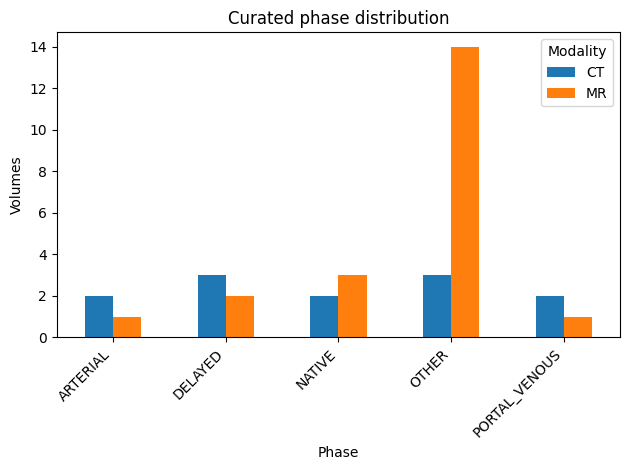

Phase provenance:


,volumes
phase_source,
fallback,17
metadata_phase_candidates,16


Phase status:


,volumes
phase_status,
UNRESOLVED,17
RESOLVED,16


Unresolved CT curation examples (3 total):


...

,patient_key,date,Modality,SeriesDescription,mri_perfusion_source,mri_dynamic_order_source,mri_dynamic_timing_source,mri_dynamic_timing_reliable,mri_sequence,phase,selection_score
3,TCGA-DD-A113,1998-12-24,CT,portal venous 3.0 B40f,NaN,NaN,NaN,NaN,NaN,PORTAL_VENOUS,230.0
10,TCGA-DD-A4NJ,2005-03-24,CT,Portal 3.0 B40f,NaN,NaN,NaN,NaN,NaN,PORTAL_VENOUS,230.0
15,TCGA-DD-A4NJ,2004-03-30,MR,Ax Vibe Post_Portal phase,explicit_text,NaN,NaN,False,T1,PORTAL_VENOUS,230.0
0,TCGA-DD-A113,1998-12-24,CT,late art. phase 3.0 B40f,NaN,NaN,NaN,NaN,NaN,ARTERIAL,225.0
8,TCGA-DD-A4NJ,2005-03-24,CT,Late Arterial 3.0 B40f,NaN,NaN,NaN,NaN,NaN,ARTERIAL,225.0
12,TCGA-DD-A4NJ,2004-03-30,MR,Ax Vibe Post_Arterial phase,explicit_text,NaN,NaN,False,T1,ARTERIAL,225.0
1,TCGA-DD-A113,1998-12-24,CT,Liver @ 10 min 3.0 B40f,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
5,TCGA-DD-A4NJ,2004-02-27,CT,5 MIN DELAY,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
9,TCGA-DD-A4NJ,2005-03-24,CT,180 sec Delay 3.0 B40f,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
13,TCGA-DD-A4NJ,2004-03-30,MR,Ax Vibe Post_Early Delayed phase,explicit_text,NaN,NaN,False,T1,DELAYED,215.0


Lowest-scoring curated selections:


,patient_key,date,Modality,SeriesDescription,mri_perfusion_source,mri_dynamic_order_source,mri_dynamic_timing_source,mri_dynamic_timing_reliable,mri_sequence,phase,selection_score
4,TCGA-DD-A113,1998-12-29,CT,AXIAL,NaN,NaN,NaN,NaN,NaN,OTHER,110.0
7,TCGA-DD-A4NJ,2004-02-27,CT,ENHANCED,NaN,NaN,NaN,NaN,NaN,OTHER,120.0
2,TCGA-DD-A113,1998-12-24,CT,liver w/o 5.0 B40f,NaN,NaN,NaN,NaN,NaN,NATIVE,170.0
11,TCGA-DD-A113,1998-12-09,MR,lava pre,explicit_text,NaN,NaN,False,T1,NATIVE,175.0
14,TCGA-DD-A4NJ,2004-03-30,MR,AX VIBE_Pre,explicit_text,NaN,NaN,False,T1,NATIVE,195.0
6,TCGA-DD-A4NJ,2004-02-27,CT,UNENHANCED,NaN,NaN,NaN,NaN,NaN,NATIVE,200.0
1,TCGA-DD-A113,1998-12-24,CT,Liver @ 10 min 3.0 B40f,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
5,TCGA-DD-A4NJ,2004-02-27,CT,5 MIN DELAY,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
9,TCGA-DD-A4NJ,2005-03-24,CT,180 sec Delay 3.0 B40f,NaN,NaN,NaN,NaN,NaN,DELAYED,215.0
13,TCGA-DD-A4NJ,2004-03-30,MR,Ax Vibe Post_Early Delayed phase,explicit_text,NaN,NaN,False,T1,DELAYED,215.0


Selected volumes by patient and modality:


studies  series  volumes
patient_key  Modality                          
TCGA-DD-A113 CT              2       5        5
             MR              1       1        1
TCGA-DD-A4NJ CT              2       6        6
             MR              1       4        4

In [75]:
# @title Inspect phase curation { display-mode: "form" }

phased = pd.read_csv('/content/imperandi-demo/tables/dicom_index_phased.csv')
selected = pd.read_csv('/content/imperandi-demo/tables/dicom_index_clean_curated.csv')

phase_counts = (
    phased.groupby(['Modality', 'phase'], dropna=False)
    .size()
    .rename('volumes')
    .reset_index()
)
print('Phase distribution by modality:')
display(phase_counts)

phase_plot = phase_counts.pivot(index='phase', columns='Modality', values='volumes').fillna(0)
ax = phase_plot.plot.bar()
ax.set_xlabel('Phase')
ax.set_ylabel('Volumes')
ax.set_title('Curated phase distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

if 'phase_source' in phased.columns:
    print('Phase provenance:')
    display(phased['phase_source'].value_counts(dropna=False).rename('volumes').to_frame())

if 'phase_status' in phased.columns:
    print('Phase status:')
    display(phased['phase_status'].value_counts(dropna=False).rename('volumes').to_frame())

    unresolved = phased.loc[phased['phase_status'].eq('UNRESOLVED')].copy()

    unresolved_ct = unresolved.loc[unresolved['Modality'].eq('CT')]
    ct_cols = [
        c for c in [
            'patient_key', 'date', 'volume_id', 'SeriesDescription',
            'phase_text_column', 'phase_text_value', 'phase_source', 'phase_reason',
            'rule_phase_reason', 'ProtocolName',
            'ImageType', 'phase'
        ]
        if c in unresolved_ct.columns
    ]
    print(f'Unresolved CT curation examples ({len(unresolved_ct)} total):')
    display(unresolved_ct[ct_cols].head(10))

    unresolved_mr = unresolved.loc[unresolved['Modality'].isin(['MR', 'MRI'])]
    mr_cols = [
        c for c in [
            'patient_key', 'date', 'volume_id', 'SeriesDescription',
            'phase_text_column', 'phase_text_value', 'phase_source', 'phase_reason',
            'rule_phase_reason', 'ProtocolName',
            'mri_perfusion_source', 'mri_dynamic_order_source',
            'mri_dynamic_timing_source', 'mri_dynamic_timing_reliable',
            'mri_sequence', 'ScanningSequence', 'SequenceName',
            'RepetitionTime', 'EchoTime', 'phase'
        ]
        if c in unresolved_mr.columns
    ]
    print(f'Unresolved MR curation examples ({len(unresolved_mr)} total):')
    display(unresolved_mr[mr_cols].head(10))

if 'phase_source' in phased.columns:
    resolved = (phased['phase_status'].eq('RESOLVED') & phased['phase_source'].eq('metadata_phase_candidates')).sum()
    print(f'Metadata-resolved phases: {resolved}/{len(phased)}')
    assert resolved > 0, 'No phases were resolved from metadata; inspect qc_unresolved_phase.csv.'

selected['selection_score'] = pd.to_numeric(selected['selection_score'], errors='coerce')
scores = selected['selection_score'].dropna()
print(f'Best-per-exam curated rows: {len(selected)}')

curated_cols = [
    c for c in [
        'patient_key', 'date', 'Modality', 'SeriesDescription',
        'mri_perfusion_source', 'mri_dynamic_order_source',
            'mri_dynamic_timing_source', 'mri_dynamic_timing_reliable',
            'mri_sequence', 'phase', 'selection_score'
    ]
    if c in selected.columns
]
ranked = selected.dropna(subset=['selection_score'])

print('Highest-scoring curated selections:')
display(ranked.nlargest(10, 'selection_score')[curated_cols])

print('Lowest-scoring curated selections:')
display(ranked.nsmallest(10, 'selection_score')[curated_cols])

print('Selected volumes by patient and modality:')
display(
    selected.groupby(['patient_key', 'Modality'])
    .agg(
        studies=('study_id', 'nunique'),
        series=('series_id', 'nunique'),
        volumes=('volume_id', 'nunique'),
    )
)

### Inspect patients missed in curation step

In [9]:
discarded_patients = set(phased.patient_key.unique()) - set(selected.patient_key.unique())
display(
    phased.loc[
        phased.patient_key.isin(discarded_patients),
         ['patient_key', 'Modality', 'mri_sequence', 'SeriesDescription', 'StudyDescription', 'ProtocolName']
        ]
)

,patient_key,Modality,mri_sequence,SeriesDescription,StudyDescription,ProtocolName
0,TCGA-BC-A10Y,MR,T1,VIBE 3D NEW 2002B,MRI ABD W+WO CONT,VIBE 3D NEW 2002B
1,TCGA-BC-A10Y,MR,T1,Subtraction_S11_S9_1,MRI ABD W+WO CONT,Subtraction
2,TCGA-BC-A10Y,MR,T1,VIBE 3D NEW 2002B,MRI ABD W+WO CONT,VIBE 3D NEW 2002B
3,TCGA-BC-A10Y,MR,T1,VIBE 3D NEW 2002B,MRI ABD W+WO CONT,VIBE 3D NEW 2002B


### Keep one representative volume per patient, date and modality
The curated CSV can contain several phases or series for an exam. For this demo, use pandas to keep just one volume per `(patient_key, date, Modality)`: the highest `selection_score`. This reduces conversion, segmentation and radiomics workload.

Write a new CSV with all original columns. The next IMPERANDI command consumes it directly, showing how e**xternal processing can fit between CSV-based pipeline steps**. The complete curated CSV remains available.

In [34]:

exam_keys = ['patient_key', 'date', 'Modality']
if selected[exam_keys].isna().any().any():
    raise ValueError('Patient, date and modality must be populated before selecting one volume per exam.')

demo_selected = (
    selected.sort_values(
        'selection_score', ascending=False, kind='stable', na_position='last',
        key=lambda scores: pd.to_numeric(scores, errors='coerce'),
    )
    .drop_duplicates(exam_keys)
    .sort_index()
    .copy()
)
demo_selected.to_csv('/content/imperandi-demo/tables/dicom_index_demo.csv', index=False)

print(f'Demo subset: {len(demo_selected)} / {len(selected)} curated volumes')
display(demo_selected[exam_keys + ['study_id', 'volume_id', 'phase', 'selection_score']])


Demo subset: 6 / 16 curated volumes


,patient_key,date,Modality,study_id,volume_id,phase,selection_score
3,TCGA-DD-A113,1998-12-24,CT,1.3.6.1.4.1.14519.5.2.1.3344.4008.254309148874...,67f2d83a3fe048f878f6e9287ccb8dd8120be142,PORTAL_VENOUS,230.0
4,TCGA-DD-A113,1998-12-29,CT,1.3.6.1.4.1.14519.5.2.1.3344.4008.339442465310...,10693827fea6590d40a6099180870cffe137a549,OTHER,110.0
5,TCGA-DD-A4NJ,2004-02-27,CT,1.3.6.1.4.1.14519.5.2.1.3344.4008.177316748388...,ca62e89d07d81292119443d8e05abd27c781aa9e,DELAYED,215.0
10,TCGA-DD-A4NJ,2005-03-24,CT,1.3.6.1.4.1.14519.5.2.1.3344.4008.178571847081...,f64e856f2bc203ddf8f48d63017bb3332e85c034,PORTAL_VENOUS,230.0
11,TCGA-DD-A113,1998-12-09,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.288087788469...,286fed735c02466d126c548eb9e7b8f9debc2b6f,NATIVE,175.0
15,TCGA-DD-A4NJ,2004-03-30,MR,1.3.6.1.4.1.14519.5.2.1.3344.4008.368700536079...,f2a5e5c298649c1bbe0a2a6a2d15d2768c6de35f,PORTAL_VENOUS,230.0


## 5. Convert selected volumes to NIfTI

Only the curated best candidates are converted, keeping the demo compact.

In [35]:
!mkdir -p /content/imperandi-demo/nifti
!imperandi convert \
  /content/imperandi-demo/tables/dicom_index_demo.csv \
  /content/imperandi-demo/nifti \
  --csv_path_out /content/imperandi-demo/tables/nifti_index.csv \
  --num_workers 2

2026-10-10 21:48:39 | INFO     | imperandi.cli | Running convert.py with arguments:
{   'archive_cache_dir': None,
    'archive_max_depth': 3,
    'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'convert',
    'csv_path': ['/content/imperandi-demo/tables/dicom_index_demo.csv'],
    'csv_path_out': '/content/imperandi-demo/tables/nifti_index.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/conv_errors.csv',
    'keep_archive_cache': False,
    'log_file': None,
    'log_level': None,
    'manifest': None,
    'num_workers': 2,
    'output_dir': '/content/imperandi-demo/nifti',
    'quiet': False,
    'resume': True,
    'strict_resume': False,
    'verbose': False}
100% 6/6 [00:07<00:00,  1.24s/it]
2026-10-10 21:48:47 | INFO     | imperandi.process.convert | Conversion summary: 6 total, 0 converted, 6 resumed, 0 skipped, 0 failed
2026-10-10 21:48:47 | INFO     | imperandi.process.convert | Conversion done ✔


### Inspect conversion results

In [36]:
nifti = pd.read_csv('/content/imperandi-demo/tables/nifti_index.csv')
converted = nifti['nifti_path'].notna().sum()
print(f'Converted volumes: {converted}/{len(nifti)}')

conversion_cols = [c for c in ['patient_key', 'date', 'Modality', 'phase', 'nifti_path'] if c in nifti.columns]
display(nifti.loc[nifti['nifti_path'].notna(), conversion_cols].head(5))


Converted volumes: 6/6


,patient_key,date,Modality,phase,nifti_path
0,TCGA-DD-A113,1998-12-24,CT,PORTAL_VENOUS,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
1,TCGA-DD-A113,1998-12-29,CT,OTHER,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
2,TCGA-DD-A4NJ,2004-02-27,CT,DELAYED,/content/imperandi-demo/nifti/TCGA-DD-A4NJ/1.3...
3,TCGA-DD-A4NJ,2005-03-24,CT,PORTAL_VENOUS,/content/imperandi-demo/nifti/TCGA-DD-A4NJ/1.3...
4,TCGA-DD-A113,1998-12-09,MR,NATIVE,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...


## 6. Segment the liver

The demo manifest deliberately requests only the liver ROI for CT and MR. The first TotalSegmentator run may download model weights.

The manifest section below configures the segmentation backend and modality-specific tasks.


In [ ]:
# @title Segmentation manifest settings { display-mode: "form" }
manifest = yaml.safe_load(manifest_path.read_text())
print(yaml.safe_dump({'segmentation': manifest['segmentation']}, sort_keys=False))


In [37]:
!imperandi segment \
  /content/imperandi-demo/tables/nifti_index.csv \
  --csv_path_out /content/imperandi-demo/tables/nifti_index_segmented.csv \
  --manifest examples/demos/demo_manifest.yaml \
  --num_workers 1

2026-10-10 21:48:49 | INFO     | imperandi.cli | Running segment.py with arguments:
{   'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'segment',
    'crop': None,
    'crop_margin_mm': None,
    'csv_path': '/content/imperandi-demo/tables/nifti_index.csv',
    'csv_path_out': '/content/imperandi-demo/tables/nifti_index_segmented.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/seg_errors.csv',
    'force': False,
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'num_workers': 1,
    'quiet': False,
    'resume': True,
    'start_method': 'spawn',
    'strict_resume': False,
    'timeout_sec': 1800,
    'verbose': False}
2026-10-10 21:48:50 | INFO     | imperandi.process.segment | MP strategy: mode=subprocess_per_case start_method=spawn workers=1 max_in_flight=1 timeout=1800s recycle_every=0 gpu_count=1 threads_per_worker=2
2026-10-10 21:48:51 | INFO     | imperandi.proce

In [76]:
# @title Inspect segmentation outputs{ display-mode: "form" }

segmented = pd.read_csv('/content/imperandi-demo/tables/nifti_index_segmented.csv')
mask_cols = [c for c in segmented.columns if c.startswith('mask_')]
segmented_ok = segmented[mask_cols].notna().any(axis=1) if mask_cols else pd.Series(False, index=segmented.index)

print('Mask columns:', mask_cols)
print(f'Segmented volumes: {segmented_ok.sum()}/{len(segmented)}')

segmentation_cols = [c for c in ['patient_key', 'date', 'Modality', 'phase', *mask_cols] if c in segmented.columns]
display(segmented.loc[segmented_ok, segmentation_cols].head(5))

pipeline_summary = pd.DataFrame({
    'stage': ['Ingested', 'Curated', 'Converted', 'Segmented'],
    'volumes': [len(clean), len(selected), int(converted), int(segmented_ok.sum())],
})
display(pipeline_summary.set_index('stage'))


Mask columns: ['mask_liver']
Segmented volumes: 6/6


,patient_key,date,Modality,phase,mask_liver
0,TCGA-DD-A113,1998-12-24,CT,PORTAL_VENOUS,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
1,TCGA-DD-A113,1998-12-29,CT,OTHER,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...
2,TCGA-DD-A4NJ,2004-02-27,CT,DELAYED,/content/imperandi-demo/nifti/TCGA-DD-A4NJ/1.3...
3,TCGA-DD-A4NJ,2005-03-24,CT,PORTAL_VENOUS,/content/imperandi-demo/nifti/TCGA-DD-A4NJ/1.3...
4,TCGA-DD-A113,1998-12-09,MR,NATIVE,/content/imperandi-demo/nifti/TCGA-DD-A113/1.3...


,volumes
stage,
Ingested,33
Curated,16
Converted,6
Segmented,6


## 7. Radiomic feature extraction

The manifest section below configures CT and MR intensity handling, resampling and radiomic feature extraction.


In [ ]:
# @title Radiomics manifest settings { display-mode: "form" }
manifest = yaml.safe_load(manifest_path.read_text())
print(yaml.safe_dump({'radiomics': manifest['radiomics']}, sort_keys=False))


In [39]:
!imperandi radiomics \
  /content/imperandi-demo/tables/nifti_index_segmented.csv \
  --csv_path_out /content/imperandi-demo/tables/nifti_index_radiomics.csv \
  --manifest examples/demos/demo_manifest.yaml \
  --skip_filter

2026-10-10 21:48:53 | INFO     | imperandi.cli | Running radiomics.py with arguments:
{   'checkpoint_every_rows': 50,
    'checkpoint_every_sec': 300,
    'command': 'radiomics',
    'csv_path': '/content/imperandi-demo/tables/nifti_index_segmented.csv',
    'csv_path_out': '/content/imperandi-demo/tables/nifti_index_radiomics.csv',
    'dry_run': False,
    'error_csv_path': '/content/imperandi-demo/tables/radiomics_errors.csv',
    'filters': {},
    'log_file': None,
    'log_level': None,
    'manifest': 'examples/demos/demo_manifest.yaml',
    'pyradiomics_settings': None,
    'quiet': False,
    'resume': True,
    'skip_filter': True,
    'strict_resume': False,
    'verbose': False}
2026-10-10 21:48:53 | INFO     | imperandi.extract.radiomics | PyRadiomics settings source: manifest
2026-10-10 21:48:53 | INFO     | imperandi.extract.radiomics | Radiomics row filters skipped via --skip_filter
2026-10-10 21:48:53 | INFO     | imperandi.extract.radiomics | PyRadiomics output disab

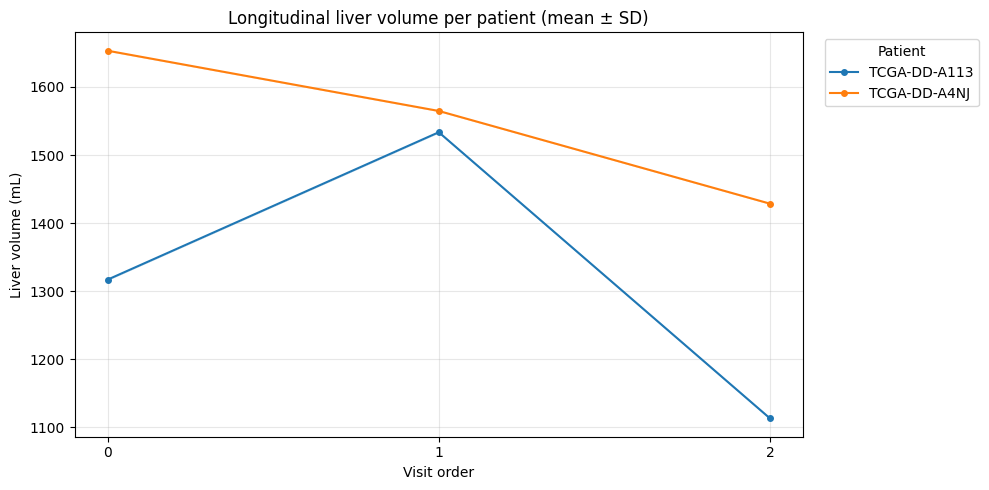

In [79]:
# @title Inspect radiomic feature evolution per patient { display-mode: "form" }

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/imperandi-demo/tables/nifti_index_radiomics.csv")

feature = "liver_original_shape_MeshVolume"
df[feature] = pd.to_numeric(df[feature], errors="coerce") / 1000  # mm³ → mL

data = (
    df.groupby(["patient_key", "visit_order"])[feature]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("visit_order")
)

fig, ax = plt.subplots(figsize=(10, 5))

for patient, group in data.groupby("patient_key"):
    x = group["visit_order"].to_numpy()
    y = group["mean"].to_numpy()
    std = group["std"].fillna(0).to_numpy()

    line, = ax.plot(x, y, "-o", label=str(patient), markersize=4)
    ax.fill_between(
        x, y - std, y + std,
        color=line.get_color(), alpha=0.15
    )

ax.set(
    xlabel="Visit order",
    ylabel="Liver volume (mL)",
    title="Longitudinal liver volume per patient (mean ± SD)",
)
ax.set_xticks(sorted(data["visit_order"].unique()))
ax.grid(alpha=0.3)
ax.legend(title="Patient", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8. Interactive viewer - explore cohort

The viewer automatically discovers populated `mask_*` columns and provides patient/exam/modality/phase navigation, orthogonal planes, windowing, overlays, and slice controls.

In [42]:
from google.colab import output
output.enable_custom_widget_manager()

%matplotlib inline

from imperandi.qc.viewer import ScanViewer

viewer = ScanViewer(
    segmented,
    'nifti_path',
    phase_col='phase',
    exploration_mode='ordered',
    isotropic_resolution_mm=1.5,
)

## 9. TorchIO preprocessing → a PyTorch batch

Use the exported NIfTI images and liver masks with [TorchIO](https://docs.torchio.org/). Preprocess up to two scans into liver-centred 128 × 128 × 128 crops at 2 mm isotropic spacing, then load one CPU batch. Images and masks share the spatial transforms; nearest-neighbour interpolation preserves mask labels. Patient, volume, visit, modality and phase identifiers travel with the batch. These crops stay in memory and leave the radiomics inputs unchanged.


In [71]:
import numpy as np
import torch
import torchio as tio

batch_rows = segmented.dropna(subset=['nifti_path', 'mask_liver'])
if batch_rows.empty:
    raise ValueError('No segmented scans are available; check the segmentation outputs.')

metadata_columns = ['patient_key', 'volume_id', 'visit_order', 'Modality', 'phase']
subjects = [
    tio.Subject(
        image=tio.ScalarImage(row['nifti_path']),
        liver=tio.LabelMap(row['mask_liver']),
        **{column: str(row[column]) for column in metadata_columns},
    )
    for _, row in batch_rows.iterrows()
]
for subject in subjects:
    subject.check_consistent_space()

spatial = tio.Compose([
    tio.ToCanonical(),
    tio.Resample(2, image_interpolation='linear',
                 label_interpolation='nearest'),
])

normalization = {
    'CT': tio.Compose([
        tio.Clamp(out_min=-150, out_max=250),
        tio.RescaleIntensity(
            in_min_max=(-150, 250),
            out_min_max=(0, 1),
        ),
    ]),
    'MR': tio.RescaleIntensity(
        out_min_max=(0, 1),
        percentiles=(1, 99),
        masking_method='liver',
    ),
}

crop = tio.CropOrPad((128, 128, 128), mask_name='liver')

def preprocessing(subject):
    subject = spatial(subject)

    modality = subject['Modality']
    subject = normalization[modality](subject)

    return crop(subject)

dataset = tio.SubjectsDataset(subjects, transform=preprocessing)
loader = tio.SubjectsLoader(dataset, batch_size=2, num_workers=0, shuffle=True)

def infinite_batches(loader):
    while True:
        yield from loader

generator = infinite_batches(loader)

In [72]:
batch = next(generator)
images = batch['image'][tio.DATA]
masks = batch['liver'][tio.DATA]

assert images.shape == masks.shape
assert np.allclose(batch['image'][tio.AFFINE], batch['liver'][tio.AFFINE])
assert set(torch.unique(masks).tolist()) <= {0, 1}
assert (masks.flatten(start_dim=1).sum(dim=1) > 0).all()

print('Image batch:', tuple(images.shape), images.dtype)
print('Mask batch:', tuple(masks.shape), masks.dtype)
print('Dimensions: batch, channel, x, y, z')
display(pd.DataFrame({column: batch[column] for column in metadata_columns}))

Image batch: (2, 1, 128, 128, 128) torch.float32
Mask batch: (2, 1, 128, 128, 128) torch.uint8
Dimensions: batch, channel, x, y, z


,patient_key,volume_id,visit_order,Modality,phase
0,TCGA-DD-A113,286fed735c02466d126c548eb9e7b8f9debc2b6f,0,MR,NATIVE
1,TCGA-DD-A4NJ,f64e856f2bc203ddf8f48d63017bb3332e85c034,2,CT,PORTAL_VENOUS


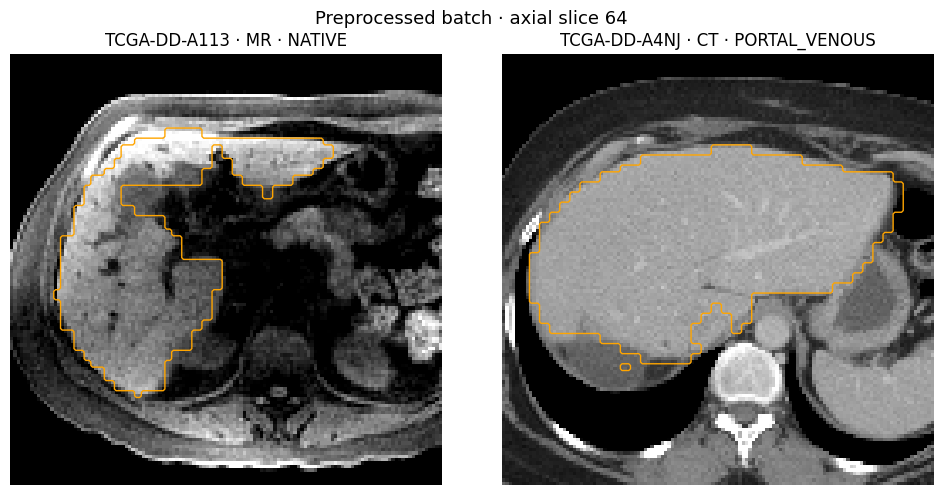

In [73]:
n = images.shape[0]
z = images.shape[-1] // 2  # middle axial slice

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), squeeze=False)

for i, ax in enumerate(axes.flat):
    image_slice = np.fliplr(images[i, 0, :, :, z].numpy().T)
    mask_slice = np.fliplr(masks[i, 0, :, :, z].numpy().T)

    ax.imshow(image_slice, cmap='gray', origin='lower', vmin=0, vmax=1)
    ax.contour(mask_slice, levels=[0.5], colors=['orange'], linewidths=1)

    ax.set_title(
        f"{batch['patient_key'][i]} · "
        f"{batch['Modality'][i]} · {batch['phase'][i]}"
    )
    ax.axis('off')

fig.suptitle(f"Preprocessed batch · axial slice {z}", fontsize=13)
plt.tight_layout()
plt.show()

## Full scientific benchmarks

This notebook is a functionality showcase. Reproducible comparisons against published TCGA-LIHC cohorts live separately under [`examples/benchmarks/`](../benchmarks/).